<a href="https://colab.research.google.com/github/SinghRaghvendra/DSPortfolio/blob/main/SMS_Spam_Detection_using_TensorFlow_in_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

APPROACH:

Load and clean an SMS spam dataset and encode labels into numeric form.

Prepare text statistics and a text vectorisation pipeline for deep learning models.

Build three TensorFlow models, i.e a dense embedding model, a Bi-LSTM model and a transfer-learning model using the Universal Sentence Encoder (USE).

Train all models with a shared helper pipeline and evaluate them on accuracy, precision, recall and F1-score.

Visualise model performance using bar and line plots to compare metrics.



In [ ]:
#Step 1: Import Libraries. We will import all the required libraries like numpy, pandas, matplotlib, seaborn, scikit-learn and TensorFlow.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow_hub as hub

In [ ]:
#Step 2: Load the Dataset. We will load the dataset.
df = pd.read_csv("/content/spam.csv", encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Step 3: Clean the dataset and encode labels
We will clean the dataset:

Drops unused columns that contain only null or irrelevant values.
Renames columns to more meaningful names i.e label (target) and Text (message).
Encodes text labels into numeric form i.e ham is 0 and spam is 1.
Shows the cleaned DataFrame with the new encoded label column.

In [ ]:
df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
df = df.rename(columns={'v1': 'label', 'v2': 'Text'})
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()

,label,Text,label_enc
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


Step 4: Split Data and convert to NumPy arrays
Here,

Splits the dataset into training (80%) and testing (20%) sets.
Uses a fixed random_state for reproducibility.
Converts pandas Series to NumPy arrays.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['Text'],
    df['label_enc'],
    test_size=0.2,
    random_state=42
)

X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

Step 5: Compute text Statistics for Vectorization

Computes the average number of words per SMS, used as sequence length for padding.
Estimates vocabulary size by counting unique tokens across all messages.
Prints basic dataset statistics for reference.

In [ ]:
avg_words_len = round(sum([len(i.split())
                      for i in df['Text']]) / len(df['Text']))
total_words_length = len(set(" ".join(df['Text']).split()))

print(f"Data Loaded. Training samples: {len(X_train_np)}")
print(f"Average words per message: {avg_words_len}")
print(f"Approximate vocabulary size: {total_words_length}")

Data Loaded. Training samples: 4457
Average words per message: 16
Approximate vocabulary size: 15686


Step 6: Helper functions for training and evaluation

compile_and_fit centralizes the compile + train logic for all models.
Uses binary_crossentropy and accuracy for binary classification.
Trains on training data and validates on the test data, returning training history.
get_metrics predicts labels, rounds probabilities to 0 or 1 and computes accuracy, precision, recall and F1-score.

In [ ]:
def compile_and_fit(model, epochs=5):
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        X_train_np,
        y_train_np,
        epochs=epochs,
        validation_data=(X_test_np, y_test_np)
    )
    return history

def get_metrics(model, X, y):
    y_preds = np.round(model.predict(X))
    return {
        'accuracy': accuracy_score(y, y_preds),
        'precision': precision_score(y, y_preds),
        'recall': recall_score(y, y_preds),
        'f1-score': f1_score(y, y_preds)
    }

Step 7: Create the TextVectorization layer

Creates a TextVectorization layer to convert raw text into integer sequences.
Limits the vocabulary size to total_words_length unique words.
Standardizes text by lowercasing and stripping punctuation.
Pads or truncates each sequence to avg_words_len tokens.
Adapts the layer on training data to learn the vocabulary distribution.

In [ ]:
from tensorflow.keras.layers import TextVectorization
text_vec = TextVectorization(
    max_tokens=total_words_length,
    standardize='lower_and_strip_punctuation',
    output_mode='int',
    output_sequence_length=avg_words_len
)
text_vec.adapt(X_train_np)

Step 8: Model 1 – Dense embedding model (build and train)

Defines an input layer that expects string tensors.
Applies the TextVectorization layer to convert text into token IDs.
Uses an Embedding layer to learn dense vector representations for each word.
Applies GlobalAveragePooling1D to compress each sequence into a single vector.
Adds a dense hidden layer with ReLU activation for non-linearity.
Outputs a single sigmoid unit for binary spam/ham prediction.
Compiles and trains the model using the shared compile_and_fit function.

In [ ]:
input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=total_words_length, output_dim=128)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model_1 = keras.Model(input_layer, output_layer, name="Dense_Model")
history_1 = compile_and_fit(model_1)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.9098 - loss: 0.2779 - val_accuracy: 0.9614 - val_loss: 0.1412
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9796 - loss: 0.0846 - val_accuracy: 0.9749 - val_loss: 0.0768
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9881 - loss: 0.0424 - val_accuracy: 0.9803 - val_loss: 0.0668
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9937 - loss: 0.0255 - val_accuracy: 0.9776 - val_loss: 0.0651
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9971 - loss: 0.0166 - val_accuracy: 0.9794 - val_loss: 0.0638


Step 9: Model 2 – Bidirectional LSTM model (build and train)

Uses the same input and text vectorization setup as Model 1.
Adds an embedding layer to convert token IDs into dense vectors.
Stacks two Bidirectional LSTM layers to capture context from both past and future tokens.
Flattens the final sequence output before feeding into dense layers.
Adds dropout to reduce overfitting.
Uses a dense hidden layer with ReLU and a sigmoid output layer for classification.
Compiles and trains this Bi-LSTM model with the helper function

In [ ]:
input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=total_words_length, output_dim=128)(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64))(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model_2 = keras.Model(input_layer, output_layer, name="BiLSTM_Model")
history_2 = compile_and_fit(model_2)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 19s 70ms/step - accuracy: 0.9414 - loss: 0.1719 - val_accuracy: 0.9704 - val_loss: 0.0963
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - accuracy: 0.9892 - loss: 0.0435 - val_accuracy: 0.9767 - val_loss: 0.0794
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 18s 100ms/step - accuracy: 0.9966 - loss: 0.0116 - val_accuracy: 0.9650 - val_loss: 0.1150
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 95ms/step - accuracy: 0.9987 - loss: 0.0041 - val_accuracy: 0.9695 - val_loss: 0.1062
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 74ms/step - accuracy: 0.9996 - loss: 0.0021 - val_accuracy: 0.9713 - val_loss: 0.1077


Step 10: Model 3 – Transfer learning with Universal Sentence Encoder (build and train)

Loads the pre-trained Universal Sentence Encoder from TensorFlow Hub.
Freezes the USE layer (trainable=False) to use it purely as a feature extractor.
Defines an input layer with scalar string input (shape=[]) as expected by USE.
Uses a Lambda layer to call USE and produce a fixed 512-dimensional sentence embedding.
Adds a dense hidden layer with 64 units and ReLU activation.
Uses dropout for regularization.
Outputs a single sigmoid unit for spam vs ham prediction.
Compiles and trains the USE-based transfer learning model with the same pipeline.

In [ ]:
use_layer = hub.KerasLayer(
    "https://tfhub.dev/google/universal-sentence-encoder/4",
    trainable=False,
    input_shape=[],
    dtype=tf.string,
    name='USE'
)
input_layer = layers.Input(shape=[], dtype=tf.string)
embedding = layers.Lambda(lambda x: use_layer(
    x), output_shape=(512,))(input_layer)
x = layers.Dense(64, activation='relu')(embedding)
x = layers.Dropout(0.2)(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)
model_3 = keras.Model(input_layer, output_layer, name="USE_Model")
history_3 = compile_and_fit(model_3)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9195 - loss: 0.3060 - val_accuracy: 0.9704 - val_loss: 0.1148
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.9767 - loss: 0.0822 - val_accuracy: 0.9803 - val_loss: 0.0695
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9856 - loss: 0.0558 - val_accuracy: 0.9821 - val_loss: 0.0586
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9870 - loss: 0.0451 - val_accuracy: 0.9830 - val_loss: 0.0550
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9886 - loss: 0.0401 - val_accuracy: 0.9848 - val_loss: 0.0528


Step 11: Collect performance metrics for all models

Evaluates each model on the same test set using the get_metrics helper.
Builds a DataFrame summarizing accuracy, precision, recall and F1-score for all models.
Prints a performance table for quick numeric comparison.

In [ ]:
results = {
    'Dense Embedding': get_metrics(model_1, X_test_np, y_test_np),
    'Bi-LSTM': get_metrics(model_2, X_test_np, y_test_np),
    'Transfer Learning (USE)': get_metrics(model_3, X_test_np, y_test_np)
}

results_df = pd.DataFrame(results).transpose()
print("Performance Table:")
print(results_df)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Performance Table:
                         accuracy  precision    recall  f1-score
Dense Embedding          0.979372   0.970149  0.872483  0.918728
Bi-LSTM                  0.971300   0.872611  0.919463  0.895425
Transfer Learning (USE)  0.984753   0.958333  0.926174  0.941980


table compares the performance of all three models on the same dataset:

Transfer Learning (USE) gives the highest overall score, especially in recall and F1-score, showing it captures patterns more effectively.
Bi-LSTM also performs slightly better than Dense Embedding because it understands sequence information.

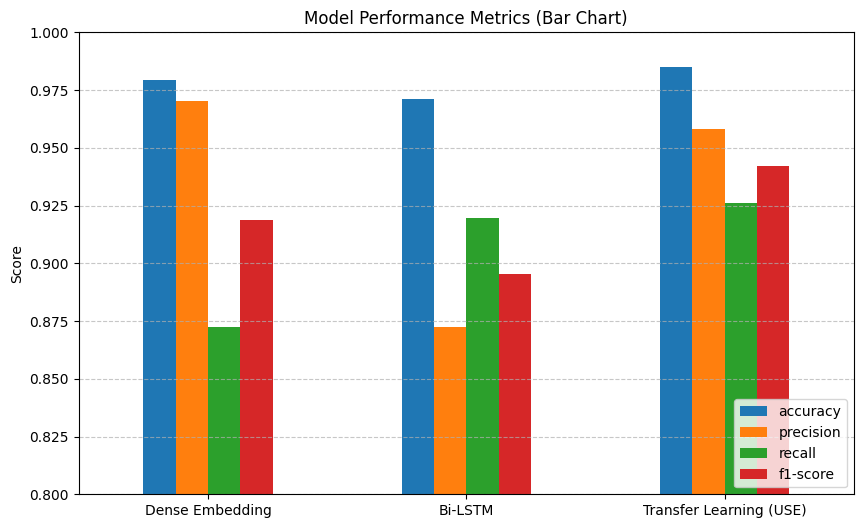

In [ ]:
#Lets Vizualize using bar chart

results_df.plot(kind='bar', figsize=(10, 6))
plt.title("Model Performance Metrics (Bar Chart)")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

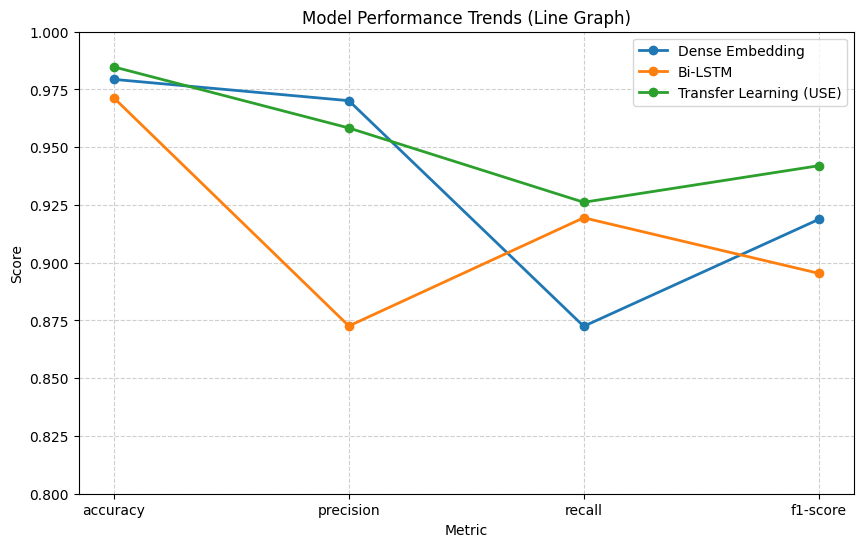

In [29]:
#Line graph vizualization

plt.figure(figsize=(10, 6))

for model_name in results_df.index:
    plt.plot(
        results_df.columns,
        results_df.loc[model_name],
        marker='o',
        label=model_name,
        linewidth=2
    )
plt.title("Model Performance Trends (Line Graph)")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0.8, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

The best performing model is 'Transfer Learning (USE)'. To integrate it into an existing project, you'll generally need to save the trained model, then load it in your project, and prepare new data for prediction.

Save the best performing model: Save the 'Transfer Learning (USE)' model to disk so it can be used later without retraining.

Load the saved model: Demonstrate how to load the saved model in a new environment or project.

Prepare new data for prediction: Show how to format new, unseen text data so it can be fed into the loaded model for predictions.

Make predictions with the loaded model: Use the loaded model to make predictions on the prepared new data.

In [33]:
import ipywidgets as widgets
from IPython.display import display, HTML

# Create UI elements
text_input = widgets.Textarea(
    value='',
    placeholder='Enter text here to check for spam...',
    description='Your Message:',
    disabled=False,
    layout=widgets.Layout(width='50%', height='100px')
)

check_button = widgets.Button(
    description='Check for Spam',
    disabled=False,
    button_style='info', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='Click to check if the message is spam'
)

output_area = widgets.Output()

# Function to handle button click and make prediction
def on_button_click(b):
    with output_area:
        output_area.clear_output()
        if text_input.value:
            # Prepare new data for prediction
            input_text_np = np.array([text_input.value])
            input_text_tf = tf.constant(input_text_np, dtype=tf.string)

            # Make prediction using the loaded model
            predictions = model_3.predict(input_text_tf)
            predicted_class = (predictions > 0.1).astype(int)[0][0]

            if predicted_class == 1:
                display(HTML("<p style='color:red; font-weight:bold;'>&#9888; SPAM DETECTED!</p>"))
            else:
                display(HTML("<p style='color:green; font-weight:bold;'>&#9989; No spam detected.</p>"))
        else:
            display(HTML("<p style='color:orange;'>Please enter some text to check.</p>"))

# Attach the function to the button's on_click event
check_button.on_click(on_button_click)

# Display the UI
display(text_input, check_button, output_area)

Textarea(value='', description='Your Message:', layout=Layout(height='100px', width='50%'), placeholder='Enter…

Button(button_style='info', description='Check for Spam', style=ButtonStyle(), tooltip='Click to check if the …

Output()

# Task
Save the "Transfer Learning (USE)" model to disk as "USE_Model", then load this saved model. After that, prepare new data, "What a great day!", "The weather is so good.", and "You won a new car!", by converting them into a NumPy array. Finally, use the loaded model to predict the class of the new data.

## Save the best performing model

### Subtask:
Save the 'Transfer Learning (USE)' model to disk so it can be used later without retraining.


**Reasoning**:
The user wants to save the 'Transfer Learning (USE)' model to disk as part of the subtask. I will use the `.save()` method of `model_3` to save it with the specified filename.



In [ ]:
model_3.save('USE_Model.keras')

**Reasoning**:
The model has been successfully saved to disk. Now, the next step is to load this saved model, as specified in the main task, to demonstrate its reusability.



In [ ]:
# Re-create the use_layer instance. This is crucial for the Lambda layer to find it.
# The name 'use_layer' here must match the name captured by the lambda in the original model.
use_layer = hub.KerasLayer(
    "https://tfhub.dev/google/universal-sentence-encoder/4",
    trainable=False,
    input_shape=[],
    dtype=tf.string,
    name='USE'
)

loaded_model = tf.keras.models.load_model(
    'USE_Model.keras',
    custom_objects={
        'KerasLayer': hub.KerasLayer, # Ensures KerasLayer type is recognized
        'use_layer': use_layer        # Provides the actual instance the lambda function closes over
    },
    safe_mode=False
)
print('Model loaded successfully.')

Model loaded successfully.


**Reasoning**:
Now that the model is loaded, I will prepare the new data by converting the given list of sentences into a NumPy array, as specified in the task.



In [ ]:
new_data = np.array([
    "What a great day!",
    "The weather is so good.",
    "You won a new car!"
])
print("New data prepared:")
print(new_data)

New data prepared:
['What a great day!' 'The weather is so good.' 'You won a new car!']


**Reasoning**:
The new data has been prepared. The next logical step, as per the main task, is to use the `loaded_model` to make predictions on this `new_data`.



In [31]:
import tensorflow_hub as hub

# Redefine use_layer to ensure it's in the global scope for prediction
use_layer = hub.KerasLayer(
    "https://tfhub.dev/google/universal-sentence-encoder/4",
    trainable=False,
    input_shape=[],
    dtype=tf.string,
    name='USE'
)

new_data_tf = tf.constant(new_data, dtype=tf.string)
predictions = loaded_model.predict(new_data_tf)
predicted_labels = (predictions > 0.5).astype(int) # Assuming 0.5 as threshold for binary classification

print("Predictions for new data:")
for i, text in enumerate(new_data):
    print(f"Text: '{text}' -> Predicted probability: {predictions[i][0]:.4f} -> Predicted class: {predicted_labels[i][0]} ({'spam' if predicted_labels[i][0] == 1 else 'ham'})")

NameError: Exception encountered when calling Lambda.call().

[1mname 'use_layer' is not defined[0m

Arguments received by Lambda.call():
  • inputs=tf.Tensor(shape=(3,), dtype=string)
  • mask=None
  • training=False

# Task
Correct the `ValueError` by converting the `new_data` NumPy array to a TensorFlow constant with `dtype=tf.string` and then use the loaded model to make predictions. Finally, print the predicted class (spam/ham) for each text.

## Correct Prediction Input

### Subtask:
Convert the `new_data` NumPy array to a TensorFlow constant with `dtype=tf.string` and then use the loaded model to make predictions. Finally, print the predicted class (spam/ham) for each text.
